### Import libraries

In [1]:
import numpy as np

from networkx.readwrite import json_graph

import seaborn as sns
import matplotlib.pyplot as plt

import json
import os

### 1.- Execution time

In [2]:
# Tiempo de ejecución de LiNGAMValidation (fast vs slow)
def plot_history_execution_time(history, export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(3, len(history['slow_time']) + 3), y=history['slow_time'], marker='o', label='Full algorithm')
    sns.lineplot(x=range(3, len(history['fast_time']) + 3), y=history['fast_time'], marker='o', label='Fast algorithm')
    plt.yscale('log')
    plt.xlabel('Number of nodes')
    plt.ylabel('Time (s)')
    plt.title('Execution time of NA-LiNGAM')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [3]:
# Tiempo de ejecución de LiNGAMValidation (fast vs slow)
def plot_history_execution_time_addition(history, export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(3, len(history['fast_time']) + 3), y=history['fast_time'], marker='o', label='Fast algorithm')
    plt.yscale('log')
    plt.xlabel('Initial nodes')
    plt.ylabel('Time (s)')
    plt.title('Execution time of NA-LiNGAM with incremental composition')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

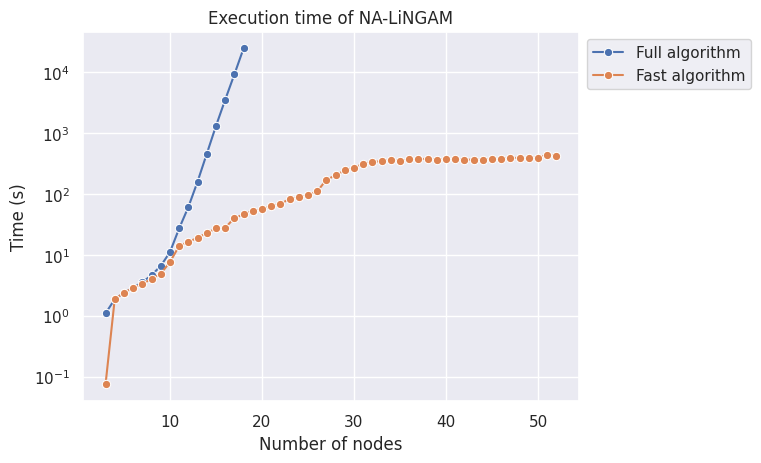

In [4]:
with open('graph_metrics/execution_time_1iter_fast_merged.json') as f:
    execution_time_history = json.load(f)
plot_history_execution_time(execution_time_history, export_pdf=False, plot_type='execution_time_v2')

In [5]:
with open('graph_metrics/execution_time_fast_addition.json') as f:
    execution_time_history_addition = json.load(f)
plot_history_execution_time_addition(execution_time_history_addition, export_pdf=True, plot_type='execution_time_incremental_composition')

### 2.- States accuracy

In [6]:
# Gráfica de elementos del estado (variables) acertados por LiNGAMValidation
def plot_history_variable_accuracy(history, export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(len(history['accuracy'])), y=history['accuracy'], marker='o', label='Fast algorithm accuracy')
    sns.lineplot(x=range(len(history['accuracy_slow'])), y=history['accuracy_slow'], marker='o', label='Full algorithm accuracy')
    plt.xlabel('Number of nodes')
    plt.ylabel('Accuracy')
    plt.title('Selected variables accuracy')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [7]:
# Gráfica de estados acertados por LiNGAMValidation
def plot_history_hits(history, export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(1,len(history['hits'])+1), y=history['hits'], marker='o', label='Fast algorithm hits')
    sns.lineplot(x=range(1,len(history['hits_slow'])+1), y=history['hits_slow'], marker='o', label='Full algorithm hits')
    plt.xlabel('Number of nodes')
    plt.ylabel('Accuracy')
    # plt.ylim(0, 1.05)
    plt.title('States accuracy')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()
    
    plt.close()

In [8]:
with open('graph_metrics/synthetic_accuracy_hits_lingam_slow_100_20.json') as f:
    synthetic_accuracy_hits = json.load(f)
plot_history_hits(synthetic_accuracy_hits, export_pdf=True, plot_type='accuracy_hits')
# plot_history_variable_accuracy(synthetic_accuracy_hits)

### 3.- Variables validation comparison

In [9]:
def plot_variable_validation_results(results, metric='AUC', export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    for method in results:
        sns.lineplot(
            x=np.arange(len(results[method])),
            y=results[method],
            label=method,
            marker='o'
        )

    plt.xlabel('Number of noise nodes')
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}_{metric}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [10]:
with open('graph_metrics/bootstrap_validation_auc_50_20.json') as f:
    bootstrap_auc = json.load(f)
plot_variable_validation_results(bootstrap_auc, 'AUC', export_pdf=True, plot_type='bootstrap_auc')

In [11]:
with open('graph_metrics/bootstrap_validation_shd_50_20.json') as f:
    bootstrap_shd = json.load(f)
plot_variable_validation_results(bootstrap_shd, 'SHD', export_pdf=True, plot_type='bootstrap_shd')

In [12]:
with open('graph_metrics/bootstrap_validation_sid_50_20.json') as f:
    bootstrap_sid = json.load(f)
plot_variable_validation_results(bootstrap_sid, 'SID', export_pdf=True, plot_type='bootstrap_sid')

### 3.1- Ablation results

In [13]:
def plot_ablation_results(results, metric='mean', type='Accuracy', export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    for method in results:
        sns.lineplot(
            x=np.arange(len(results[method][metric])),
            y=results[method][metric],
            label=method,
            marker='o'
        )

    plt.xlabel('Number of noise nodes')
    plt.ylabel(type)
    plt.title(type)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}_{metric}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [14]:
def plot_ablation_results(results, metric='AUC', export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    markers = ['.', 'o', 's', '^', 'v', 'D', 'P', '*', 'h', 'X']
    
    for method in results:
        if method == 'Complete':
            is_highlighted = True
        else:
            is_highlighted = False

        #lw = 3.5 if is_highlighted else 1.5
        alpha = 1.0 if is_highlighted else 0.5
        z = 5 if is_highlighted else 1

        sns.lineplot(
            x=np.arange(len(results[method][metric])),
            y=results[method][metric],
            label=method,
            marker=markers.pop(0) if markers else 'o',
            #linewidth=lw,
            alpha=alpha,
            zorder=z
        )

    plt.xlabel('Number of noise nodes')
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}_{metric}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [15]:
with open('graph_metrics/real_results_ada_ablation_20_noise_20_iter.json') as f:
    real_ablation_metrics = json.load(f)
plot_ablation_results(real_ablation_metrics, 'AUC', export_pdf=True, plot_type='ada_ablation_lingam')
plot_ablation_results(real_ablation_metrics, 'SID', export_pdf=True, plot_type='ada_ablation_lingam')
plot_ablation_results(real_ablation_metrics, 'SHD', export_pdf=True, plot_type='ada_ablation_lingam')

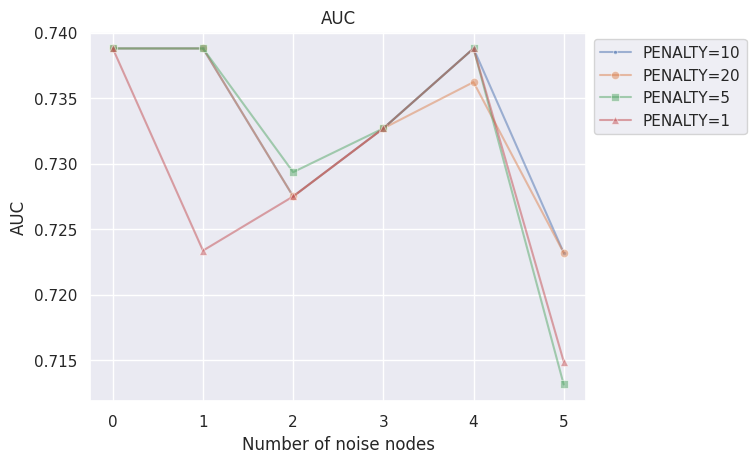

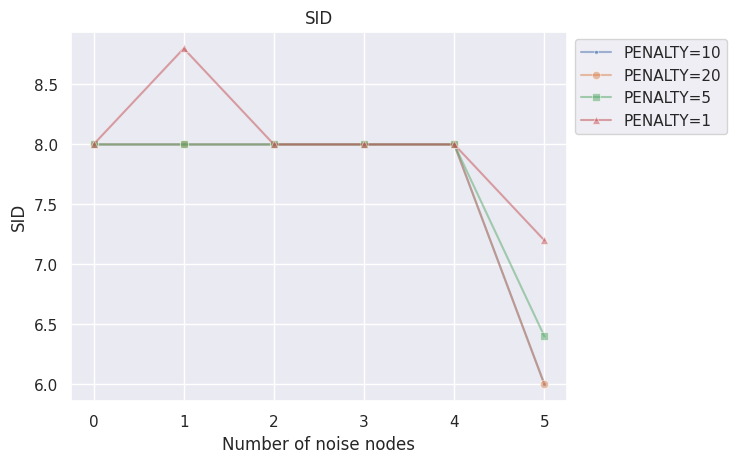

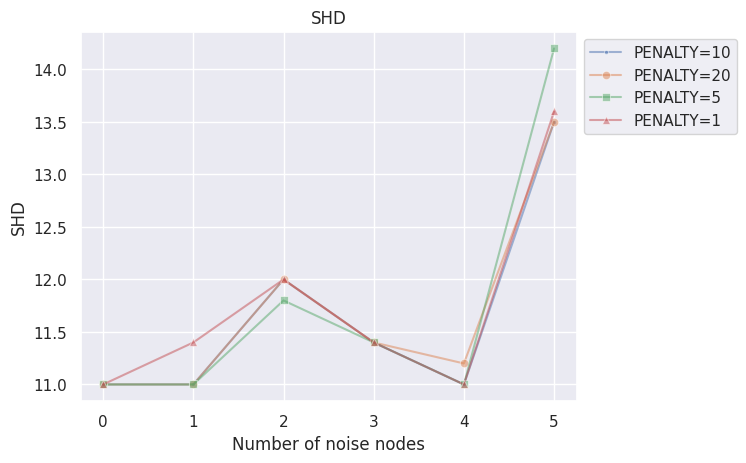

In [16]:
with open('graph_metrics/real_results_ada_ablation_penalty_20_noise_20_iter.json') as f:
    real_ablation_metrics = json.load(f)
plot_ablation_results(real_ablation_metrics, 'AUC', export_pdf=False, plot_type='ada_ablation_penalty_lingam')
plot_ablation_results(real_ablation_metrics, 'SID', export_pdf=False, plot_type='ada_ablation_penalty_lingam')
plot_ablation_results(real_ablation_metrics, 'SHD', export_pdf=False, plot_type='ada_ablation_penalty_lingam')

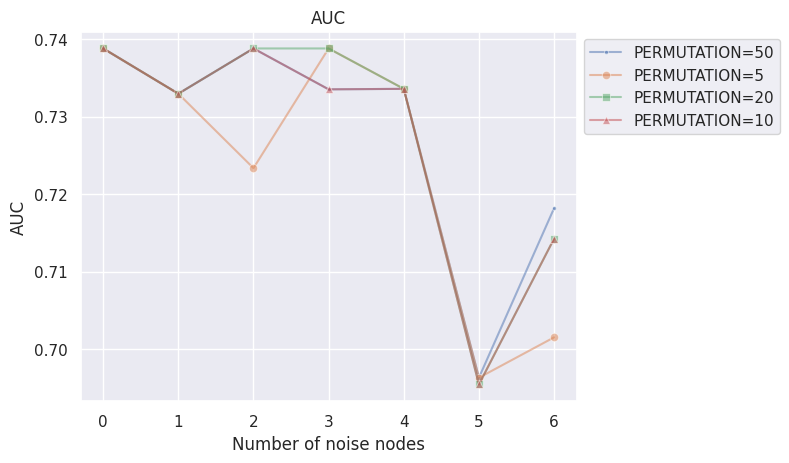

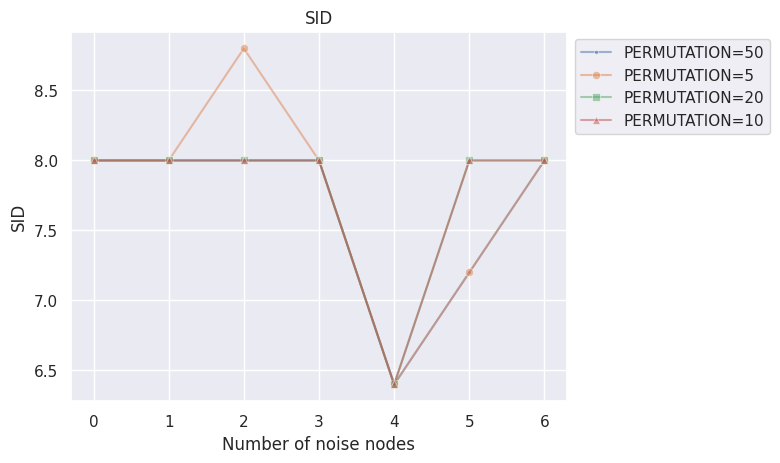

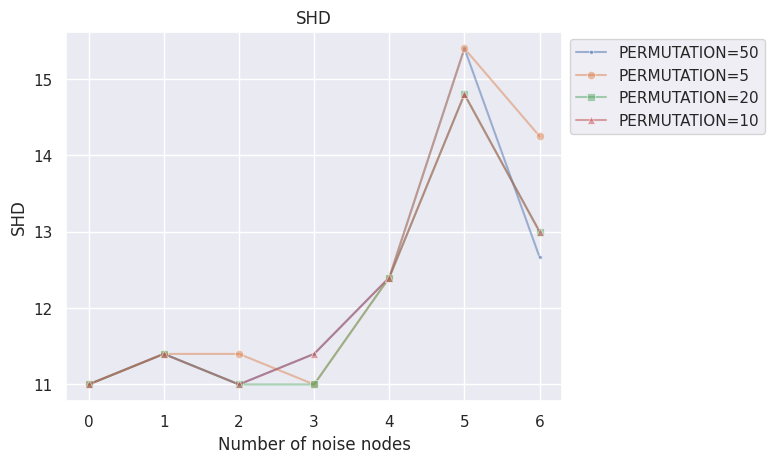

In [17]:
with open('graph_metrics/real_results_ada_ablation_permutation_20_noise_20_iter.json') as f:
    real_ablation_metrics = json.load(f)
plot_ablation_results(real_ablation_metrics, 'AUC', export_pdf=False, plot_type='ada_ablation_permutation_lingam')
plot_ablation_results(real_ablation_metrics, 'SID', export_pdf=False, plot_type='ada_ablation_permutation_lingam')
plot_ablation_results(real_ablation_metrics, 'SHD', export_pdf=False, plot_type='ada_ablation_permutation_lingam')

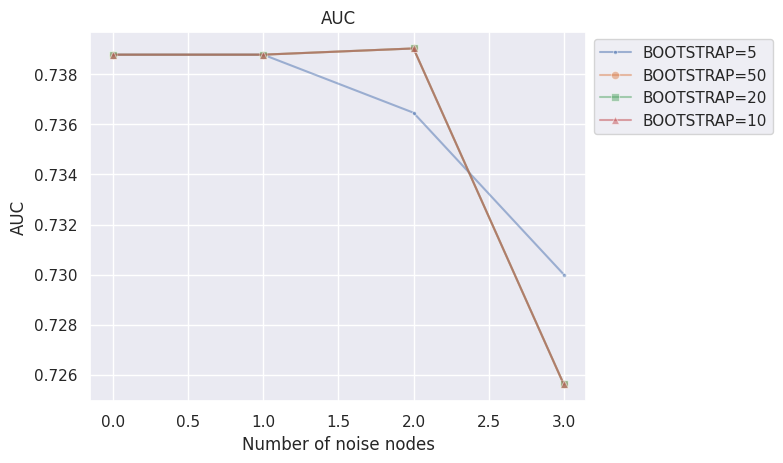

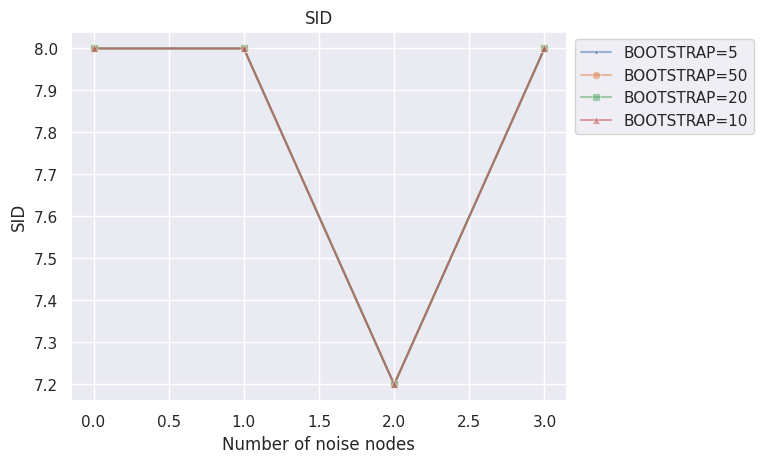

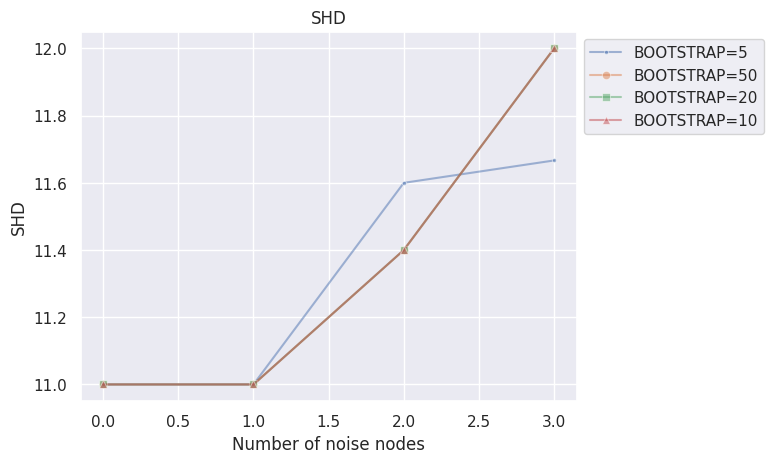

In [18]:
with open('graph_metrics/real_results_ada_ablation_bootstrap_20_noise_20_iter.json') as f:
    real_ablation_metrics = json.load(f)
plot_ablation_results(real_ablation_metrics, 'AUC', export_pdf=False, plot_type='ada_ablation_bootstrap_lingam')
plot_ablation_results(real_ablation_metrics, 'SID', export_pdf=False, plot_type='ada_ablation_bootstrap_lingam')
plot_ablation_results(real_ablation_metrics, 'SHD', export_pdf=False, plot_type='ada_ablation_bootstrap_lingam')

### 4.- Causal discovery results

In [ ]:
def plot_metrics_results(results, metric='AUC', export_pdf=False, plot_type=None):
    sns.set(style="darkgrid")
    markers = ['.', 'o', 's', '^', 'v', 'D', 'P', '*', 'h', 'X']
    
    for method in results:
        sns.lineplot(
            x=np.arange(len(results[method][metric])),
            y=results[method][metric],
            label=method,
            marker=markers.pop(0) if markers else 'o'
        )

    plt.xlabel('Number of noise nodes')
    plt.ylabel(metric)
    plt.title(metric)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

    if export_pdf:
        if plot_type is None:
            plot_type = ''
        if not os.path.exists('figures'):
            os.makedirs('figures')
        plt.savefig(f'figures/{plot_type}_{metric}.pdf', format='pdf', bbox_inches='tight')
    else:
        plt.show()

    plt.close()

In [ ]:
with open('graph_metrics/real_results_ada_lingam_20_noise_50_iter.json') as f:
    real_metrics = json.load(f)
plot_metrics_results(real_metrics, 'AUC', export_pdf=True, plot_type='ada_lingam')
plot_metrics_results(real_metrics, 'SID', export_pdf=True, plot_type='ada_lingam')
plot_metrics_results(real_metrics, 'SHD', export_pdf=True, plot_type='ada_lingam')

In [ ]:
with open('graph_metrics/real_results_ada_all_20_noise_20_iter.json') as f:
    real_metrics = json.load(f)
plot_metrics_results(real_metrics, 'AUC', export_pdf=True, plot_type='ada_all')
plot_metrics_results(real_metrics, 'SID', export_pdf=True, plot_type='ada_all')
plot_metrics_results(real_metrics, 'SHD', export_pdf=True, plot_type='ada_all')

In [ ]:
with open('graph_metrics/real_results_all_20_noise_20_iter.json') as f:
    real_metrics = json.load(f)
plot_metrics_results(real_metrics, 'AUC', export_pdf=True, plot_type='real_all')
plot_metrics_results(real_metrics, 'SID', export_pdf=True, plot_type='real_all')
plot_metrics_results(real_metrics, 'SHD', export_pdf=True, plot_type='real_all')
# plot_metrics_results(real_metrics, 'Edges Accuracy')
# plot_metrics_results(real_metrics, 'Invented Edges Accuracy')
# plot_metrics_results(real_metrics, 'Invented Wrong Edges Accuracy')

In [ ]:
with open('graph_metrics/real_results_lingam_20_noise_50_iter.json') as f:
    real_metrics = json.load(f)
plot_metrics_results(real_metrics, 'AUC', export_pdf=True, plot_type='real_lingam')
plot_metrics_results(real_metrics, 'SID', export_pdf=True, plot_type='real_lingam')
plot_metrics_results(real_metrics, 'SHD', export_pdf=True, plot_type='real_lingam')
# plot_metrics_results(real_metrics, 'Edges Accuracy')
# plot_metrics_results(real_metrics, 'Invented Edges Accuracy')
# plot_metrics_results(real_metrics, 'Invented Wrong Edges Accuracy')

In [ ]:
with open('graph_metrics/synthetic_results_all_20_noise_20_iter.json') as f:
    synthetic_metrics = json.load(f)
plot_metrics_results(synthetic_metrics, 'AUC', export_pdf=True, plot_type='synthetic_all')
plot_metrics_results(synthetic_metrics, 'SID', export_pdf=True, plot_type='synthetic_all')
plot_metrics_results(synthetic_metrics, 'SHD', export_pdf=True, plot_type='synthetic_all')
# plot_metrics_results(synthetic_metrics, 'Edges Accuracy')
# plot_metrics_results(synthetic_metrics, 'Invented Edges Accuracy')
# plot_metrics_results(synthetic_metrics, 'Invented Wrong Edges Accuracy')

In [ ]:
with open('graph_metrics/synthetic_results_lingam_20_noise_100_iter.json') as f:
    synthetic_metrics = json.load(f)
plot_metrics_results(synthetic_metrics, 'AUC', export_pdf=True, plot_type='synthetic_lingam')
plot_metrics_results(synthetic_metrics, 'SID', export_pdf=True, plot_type='synthetic_lingam')
plot_metrics_results(synthetic_metrics, 'SHD', export_pdf=True, plot_type='synthetic_lingam')
# plot_metrics_results(synthetic_metrics, 'Edges Accuracy')
# plot_metrics_results(synthetic_metrics, 'Invented Edges Accuracy')
# plot_metrics_results(synthetic_metrics, 'Invented Wrong Edges Accuracy')